<a href="https://colab.research.google.com/github/1up9059/tareas_curso_NLP/blob/Tareas/NLP_Tarea_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 4

In [ ]:
!pip -q install sklearn-crfsuite seqeval

In [ ]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import math

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
import sklearn_crfsuite
from sklearn_crfsuite import metrics
from seqeval.metrics import classification_report as seqeval_classification_report

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#torch.manual_seed(0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Lectura de archivos

 Leer los archivos csv esp.train y esp.testb en dos data frames diferentes. Al leerlos debe de asegurarse de que las comillas no sean tratadas en forma especial. Además, no debe interpretarse la primera fila como encabezados, sino que debe definir los encabezados como **Word, POS y Tag**

Definimos las funcione que nos ayudaran a leer los archivos de datos

In [ ]:
def separator_tracker(path: Path, separators: list, sample_size: int = 4096,) -> str:
    """return the most recurrent separator in the file"""
    with path.open('r', newline='') as f:
        sample = f.read(sample_size)
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=separators).delimiter
        return dialect
    except csv.Error:
        # if there i a fail, returns None
        return None

In [ ]:
def read_csv_files(folder_path: Path, separators: list, names: list) -> dict:
  """
  Here we read the csv files
  Parameters: folder_path: Path
  """
  folder_path = Path(folder_path)
  csv_files = list(folder_path.glob('*.csv'))
  data_df = {}

  for csv_file in csv_files:
    try:
      sep = separator_tracker(csv_file, separators)
      df = pd.read_csv(csv_file, sep=sep, header= None, names=names, engine='python', quoting=csv.QUOTE_NONE, dtype=str)
      #key = str(csv_file).split('/')[-1].split('.')[0]#take the file name without .csv as key for the dict
      key=csv_file.stem
      data_df[key] = df

    except Exception as e:
      print(f"Error reading {csv_file}: {e}")

  return data_df

In [ ]:
separators = [r"\s+"]
names = ['Word','POS','Tag']
folder_path = '/content/drive/MyDrive/source_NLP/Tarea_4/'

In [ ]:
files = read_csv_files(folder_path, separators, names)
files.keys()

dict_keys(['esp_train', 'esp_testa', 'esp_testb'])

Lectura de los dataframes de datos:

In [ ]:
esp_train_df = files[list(files.keys())[0]]
esp_testa_df = files[list(files.keys())[1]]
esp_testb_df = files[list(files.keys())[2]]

In [ ]:
dfs = {'esp_train_df': esp_train_df, 'esp_testa_df': esp_testa_df, 'esp_testb_df': esp_testb_df}

## 2. Modificacion de los datos mediante POS y NER para modelos HMM y CRF

Eche un vistazo a los datos y comente. ¿Cuál es la distribución del tamaño de las oraciones? ¿Cuál es la distribución de las etiquetas **POS**? ¿Es balanceada? ¿Cuál es la distribución de las etiquetas **Tag**? ¿Es balanceada?

In [ ]:
def add_sentence_by_backfill(df: pd.DataFrame) -> pd.DataFrame:
    # Crea la columna
    df = df.copy()
    df["sentence"] = pd.NA

    # Numera solo en filas con Fp
    mask_fp = df["POS"].eq("Fp")
    df.loc[mask_fp, "sentence"] = range(1, mask_fp.sum() + 1)

    # Copiar esos números hacia atrás (backfill "hacia arriba")
    df["sentence"] = df["sentence"][::-1].ffill()[::-1]

    # Si el archivo NO termina en Fp, quedarán NaNs al final -> así los resolvemos
    if df["sentence"].isna().any():
        last_num = pd.to_numeric(df["sentence"], errors="coerce").max()
        last_num = 0 if pd.isna(last_num) else int(last_num)
        df.loc[df["sentence"].isna(), "sentence"] = last_num + 1

    # Asegurar tipo entero
    df["sentence"] = df["sentence"].astype(int)
    return df

In [ ]:
tr_stid_df = add_sentence_by_backfill(esp_train_df)
ta_stid_df = add_sentence_by_backfill(esp_testa_df)
tb_stid_df = add_sentence_by_backfill(esp_testb_df)

/tmp/ipython-input-3624541518.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentence"] = df["sentence"][::-1].ffill()[::-1]
/tmp/ipython-input-3624541518.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentence"] = df["sentence"][::-1].ffill()[::-1]


In [ ]:
tb_stid_df

,Word,POS,Tag,sentence
0,La,DA,B-LOC,1
1,Coruña,NC,I-LOC,1
2,",",Fc,O,1
3,23,Z,O,1
4,may,NC,O,1
...,...,...,...,...
51528,relojes,NC,O,1364
51529,",",Fc,O,1364
51530,entre,SP,O,1364
51531,otros,PI,O,1364


## 3. Balnce de datos

Eche un vistazo a los datos y comente ¿Cuál es la distribución del tamaño de las oraciones? ¿Cuál es la distribución de als etiquetas **POS** ¿Es balanceada? ¿Cual es la distribución de las etiquetas **Tag**?¿Es balanceada?

In [ ]:
def analyze_sentence_lengths(df:pd.DataFrame, name:str):
    lengths = df.groupby("sentence").size()
    print(f"Estadísticas de longitud de oraciones, {name}:")
    print(lengths.describe())

    plt.figure(figsize=(8,4))
    lengths.hist(bins=30)
    plt.title(f"Distribución de longitud de oraciones {name}")
    plt.xlabel("Número de palabras por oración")
    plt.ylabel("Frecuencia")
    plt.show()

In [ ]:
def analyze_pos_distribution(df:pd.DataFrame, name:str):
    pos_counts = df["POS"].value_counts(normalize=True) * 100
    print(f"Distribución de etiquetas POS (%), {name}:")
    #print(pos_counts)
    #print(df.describe(include="all"))
    plt.figure(figsize=(8,4))
    pos_counts.plot(kind="bar")
    plt.title("Distribución de etiquetas POS")
    plt.ylabel("Porcentaje (%)")
    plt.show()

In [ ]:
def analyze_ner_distribution(df:pd.DataFrame, name:str):
    tag_counts = df["Tag"].value_counts(normalize=True) * 100
    print(f"Distribución de etiquetas NER (%), {name}:")
    #print(tag_counts)
    #print(df.describe(include="all"))
    plt.figure(figsize=(8,4))
    tag_counts.plot(kind="bar")
    plt.title("Distribución de etiquetas NER")
    plt.ylabel("Porcentaje (%)")
    plt.show()

In [ ]:
def analyze_column(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Analiza una columna de un DataFrame y devuelve un resumen con:
    - conteo absoluto
    - porcentaje relativo

    Parámetros:
    df : pd.DataFrame
        El DataFrame a analizar
    col : str
        El nombre de la columna a resumir

    Retorna:
    pd.DataFrame con columnas ["value", "count", "percent"]
    """
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({
        "value": counts.index,
        "count": counts.values,
        "percent": percents.values
    })
    return summary.reset_index(drop=True)

Estadísticas de longitud de oraciones, Training Dataset:
count    7263.000000
mean       36.447060
std        23.599953
min         1.000000
25%        22.000000
50%        38.000000
75%        49.000000
max      1239.000000
dtype: float64


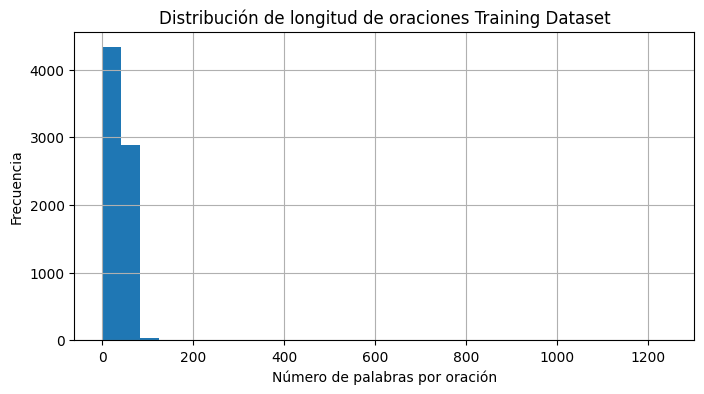

Estadísticas de longitud de oraciones, Test A Dataset:
count    1640.000000
mean       32.270122
std        18.234479
min         1.000000
25%        16.000000
50%        33.000000
75%        45.000000
max       142.000000
dtype: float64


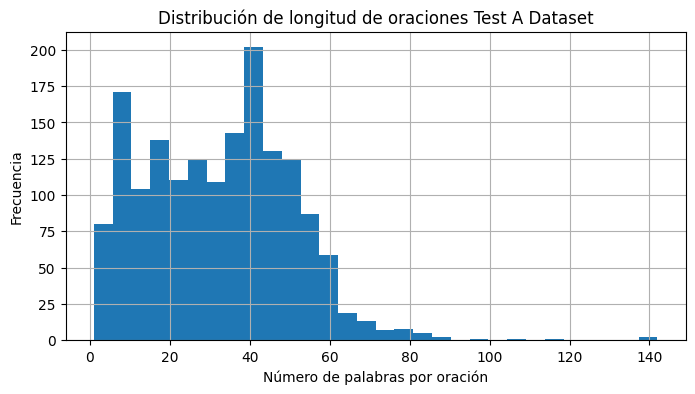

Estadísticas de longitud de oraciones, Test B Dataset:
count    1364.000000
mean       37.780792
std        17.885128
min         2.000000
25%        27.000000
50%        40.000000
75%        50.000000
max       203.000000
dtype: float64


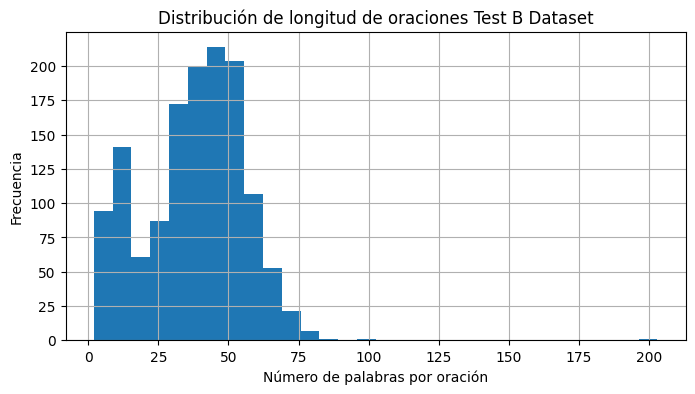

In [ ]:
analyze_sentence_lengths(tr_stid_df, "Training Dataset")
analyze_sentence_lengths(ta_stid_df, "Test A Dataset")
analyze_sentence_lengths(tb_stid_df, "Test B Dataset")


Distribución de etiquetas POS (%), Training Dataset:


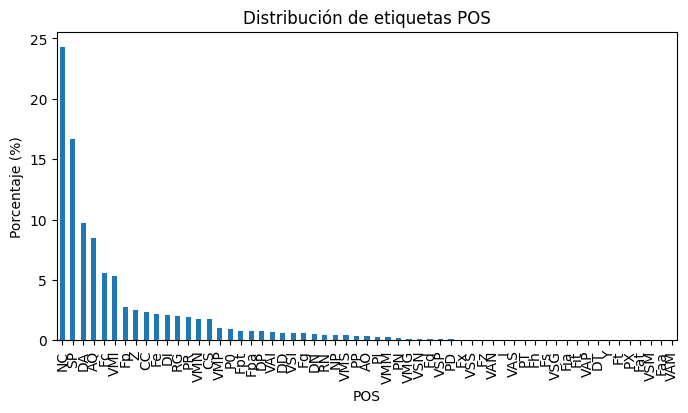

Distribución de etiquetas POS (%), Test A Dataset:


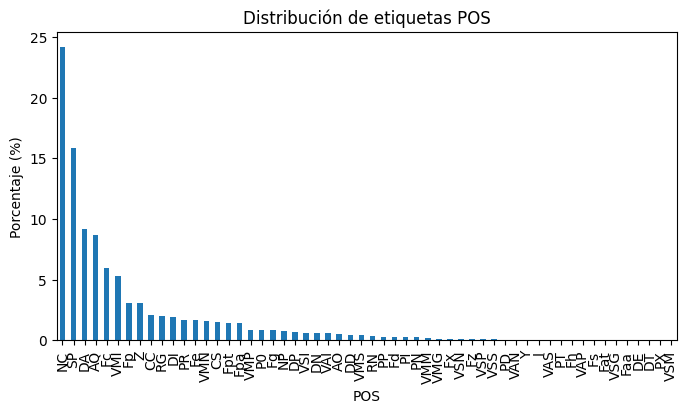

Distribución de etiquetas POS (%), Test B Dataset:


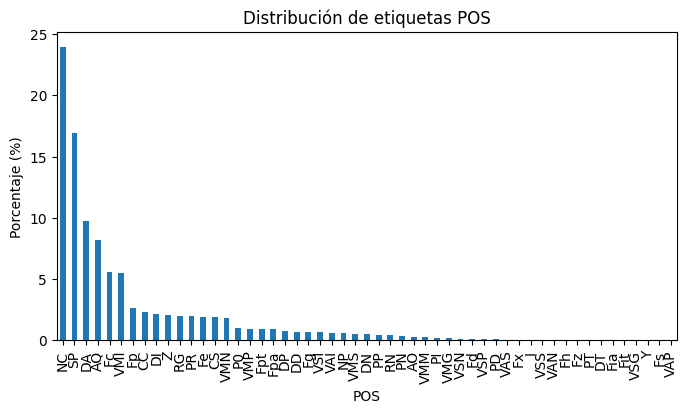

In [ ]:
analyze_pos_distribution(tr_stid_df, "Training Dataset")
analyze_pos_distribution(ta_stid_df, "Test A Dataset")
analyze_pos_distribution(tb_stid_df, "Test B Dataset")

Distribución de etiquetas NER (%), Training Dataset:


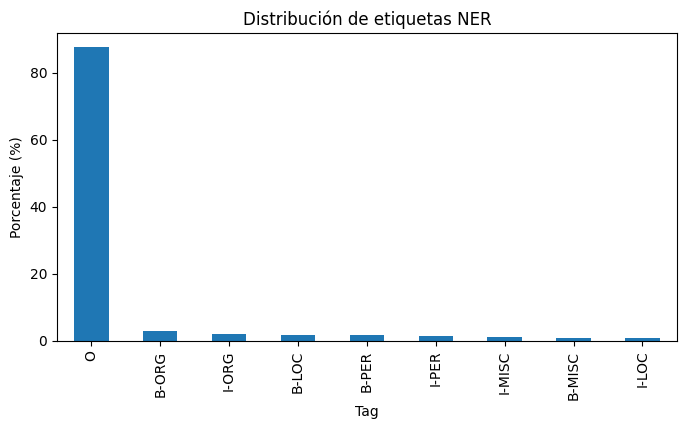

Distribución de etiquetas NER (%), Test A Dataset:


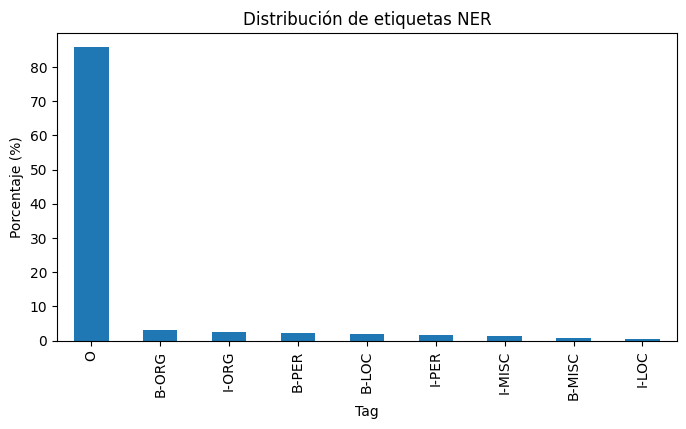

Distribución de etiquetas NER (%), Test B Dataset:


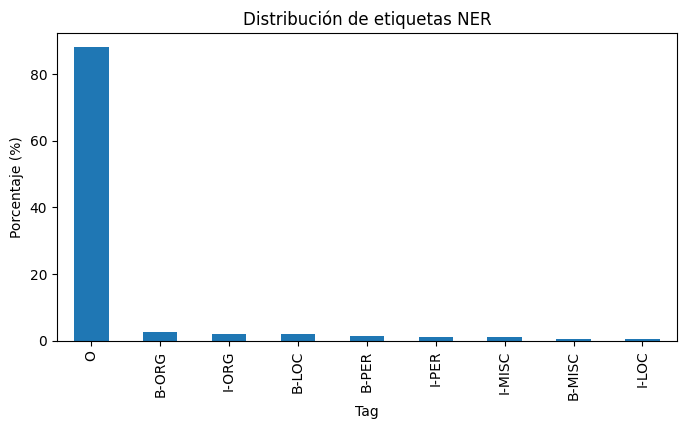

In [ ]:
analyze_ner_distribution(tr_stid_df, "Training Dataset")
analyze_ner_distribution(ta_stid_df, "Test A Dataset")
analyze_ner_distribution(tb_stid_df, "Test B Dataset")

### Statistical Analisis (Conformation %)

#### 1. Analisis for Training dataset

In [ ]:
pos_summary = analyze_column(tr_stid_df, "POS")
print("Statistical analisis for POS distribution")
print(pos_summary.head(10))

Statistical analisis for POS distribution
  value  count    percent
0    NC  64326  24.300096
1    SP  44022  16.629961
2    DA  25679   9.700621
3    AQ  22418   8.468731
4    Fc  14716   5.559186
5   VMI  14036   5.302306
6    Fp   7263   2.743705
7     Z   6589   2.489092
8    CC   6248   2.360274
9    Fe   5691   2.149859


In [ ]:
ner_summary = analyze_column(tr_stid_df, "Tag")
print("Statistical analisis for Tag distribution")
print(ner_summary)

Statistical analisis for Tag distribution
    value   count    percent
0       O  231920  87.611205
1   B-ORG    7390   2.791682
2   I-ORG    4992   1.885802
3   B-LOC    4913   1.855958
4   B-PER    4321   1.632322
5   I-PER    3903   1.474416
6  I-MISC    3212   1.213380
7  B-MISC    2173   0.820883
8   I-LOC    1891   0.714353


#### 2. Analisis for test A dataset

In [ ]:
pos_summary = analyze_column(ta_stid_df, "POS")
print("Statistical analisis for POS distribution")
print(pos_summary.head(10))

Statistical analisis for POS distribution
  value  count    percent
0    NC  12796  24.178524
1    SP   8382  15.838104
2    DA   4861   9.185042
3    AQ   4603   8.697542
4    Fc   3135   5.923700
5   VMI   2799   5.288816
6    Fp   1639   3.096952
7     Z   1622   3.064830
8    CC   1097   2.072823
9    RG   1053   1.989683


In [ ]:
ner_summary = analyze_column(ta_stid_df, "Tag")
print("Statistical analisis for Tag distribution")
print(ner_summary)

Statistical analisis for Tag distribution
    value  count    percent
0       O  45356  85.701869
1   B-ORG   1700   3.212214
2   I-ORG   1366   2.581108
3   B-PER   1222   2.309015
4   B-LOC    984   1.859305
5   I-PER    859   1.623113
6  I-MISC    654   1.235758
7  B-MISC    445   0.840844
8   I-LOC    337   0.636774


#### 3. Analisis for test B dataset

In [ ]:
pos_summary = analyze_column(ta_stid_df, "POS")
print("Statistical analisis for POS distribution")
print(pos_summary.head(10))

Statistical analisis for POS distribution
  value  count    percent
0    NC  12796  24.178524
1    SP   8382  15.838104
2    DA   4861   9.185042
3    AQ   4603   8.697542
4    Fc   3135   5.923700
5   VMI   2799   5.288816
6    Fp   1639   3.096952
7     Z   1622   3.064830
8    CC   1097   2.072823
9    RG   1053   1.989683


In [ ]:
ner_summary = analyze_column(tb_stid_df, "Tag")
print("Statistical analisis for Tag distribution")
print(ner_summary)

Statistical analisis for Tag distribution
    value  count    percent
0       O  45355  88.011565
1   B-ORG   1400   2.716706
2   I-ORG   1104   2.142317
3   B-LOC   1084   2.103506
4   B-PER    735   1.426271
5   I-PER    634   1.230280
6  I-MISC    557   1.080861
7  B-MISC    339   0.657831
8   I-LOC    325   0.630664


# 4. Aplicación modelo *CategoricalHMM*

Aplicar el modelo CategoricalHMM visto en clase usando esp.train como datos de entrenamiento y esp.testb como datos de prueba.

Cambiamos los nombres para poder identificar mejor.

In [ ]:
train_df = tr_stid_df
testb_df = tb_stid_df

Luego definimos la función **df_to_sentences** que toma el dataframe de las oraciones y las agrupa por la columna **sentence** asumiendo que cada valor unico representa un oración, lo que agrupa todas las filas bajo la misma oración. Luego basandose en las columnas **Word** y **POS**, y combiertee estas columnas en listas a cada grupo y luego generar una lista de estas listas.  

In [ ]:
def df_to_sentences(df: pd.DataFrame, word_col="Word", pos_col="POS") -> tuple:
    """
    Convierte el DataFrame a listas de oraciones:
    - X: lista de listas de palabras
    - Y: lista de listas de POS
    """
    grouped = df.groupby("sentence")
    X = grouped[word_col].apply(list).tolist()
    Y = grouped[pos_col].apply(list).tolist()
    return X, Y

Luego definimos la función **Build_vocab_with_unk** crea un vocabulario desde la lista de tokens, incluyendo un manejo de probabilidades para palabras desconocidas reemplazandolas por **unk** (unknown), bajo una frecuencia minima de 2, esto quiere decir que en la secuencia de test, cuando se pruebe el modelo y que entonces el modelo no se rompa al ser evaluado.

In [ ]:
def build_vocab_with_unk(train_tokens, min_freq=2):
    """
    Crea vocabulario de palabras con umbral de frecuencia y agrega <UNK>.
    Retorna: vocab_index (dict), word2id (dict), id2word (list)
    """
    counts = Counter([w for sent in train_tokens for w in sent])
    # Palabras frecuentes + UNK
    vocab = [w for w,c in counts.items() if c >= min_freq]
    vocab = sorted(vocab)
    id2word = ["<UNK>"] + vocab
    word2id = {w:i for i,w in enumerate(id2word)}
    return word2id, id2word

Se define la funcion **map_tokens_to_ids** que convierte las secuencias de tokens en secuencias numericas de IDs, basado en el mapeo proporcionado, manteniendo el unknow token *UNK* en el proceso.

In [ ]:
def map_tokens_to_ids(seqs, mapping, unk_token="<UNK>"):
    unk_id = mapping[unk_token]
    return [[mapping.get(w, unk_id) for w in sent] for sent in seqs]

La funcion **build_state_maps** toma la lista de listas *y_sequence* y recorre las etiquetas de todas las oraciones que tienen POS, elimina los duplicados si es que los hay y las ordena alfabeticamente. Finalmente asígna a cada estado un indice entero en state2id, mientras que en id2state hace lo inverso creando dos diccionarios y devolviendolos junto a los estados

In [ ]:
def build_state_maps(y_sequences):
    """Crea mapping de estados (POS)."""
    states = sorted(set(tag for sent in y_sequences for tag in sent))
    state2id = {s:i for i,s in enumerate(states)}
    id2state = {i:s for s,i in state2id.items()}
    return states, state2id, id2state

AHora, la función **count_hmm_sufficient_stats** primero realiza calculos de cuantas veces las oraciones, luego cuantas veces se observa la transformación entre el estado i y el estado j, y cuantas veces el estado s tiene a w. Luego se recorren las palabras en *x_sent* y las etiquetas en *y_set*, y si la oración esta vacia, entonces se salta. Luego se realiza el contedo para el estado *s*. El primer *for* convierte los POS al indice *s* y suma 1. Luego, el segundo *for* recorre los pares de estados consecutivos de la ooración convirtiendo ambos indices i, j, de modo qu esi en la oración aparece por ejemplo "DA" y transforma a "NC"  entonces se suma 1.

In [ ]:
def count_hmm_sufficient_stats(X_ids, Y_states, state2id, V):
    """Conteos de inicios, transiciones y emisiones."""
    S = len(state2id)
    start_counts = np.zeros(S, dtype=np.float64)
    trans_counts = np.zeros((S, S), dtype=np.float64)
    emit_counts  = np.zeros((S, V), dtype=np.float64)

    for x_sent, y_sent in zip(X_ids, Y_states):
        if not x_sent:
            continue
        s0 = state2id[y_sent[0]]
        start_counts[s0] += 1.0
        for w_id, s_str in zip(x_sent, y_sent):
            s = state2id[s_str]
            emit_counts[s, w_id] += 1.0
        for s_prev, s_next in zip(y_sent[:-1], y_sent[1:]):
            i = state2id[s_prev]
            j = state2id[s_next]
            trans_counts[i, j] += 1.0
    return start_counts, trans_counts, emit_counts

La función *normalize_with_laplace* aplica un suavizado de laplace, primero sumando alpha que asegura que nunca haya probabilidad, se calcula el denominador para dividir el valor de cada celda, obteniendo la probabilidad, en este paso tambien se protege de que haya división por 0. Asi nuestros datos quedan solo de 0 a 1.

In [ ]:
def normalize_with_laplace(counts, alpha, axis=None):
    """(counts + alpha) / sum(counts + alpha). Si axis es None, escalar."""
    smoothed = counts + alpha
    denom = smoothed.sum(axis=axis, keepdims=(axis is not None))
    # evitar divisiones por cero si hay filas vacías (no debería, pero por robustez)
    if np.isscalar(denom) or isinstance(denom, np.float64):
        if denom == 0.0:
            denom = 1.0
    else:
        denom[denom == 0.0] = 1.0

    return smoothed / denom

La función **train_categorical_hmm** calcula los conteos de inicios, transiciones y emisiones. Luego los convierte en probabilidades suavizadas con laplace, luego pasamos esso a los *log_space* del diccionario params, en logaritmo, eso es el modelo hmm.

In [ ]:
def train_categorical_hmm(X_ids, Y_states, state2id, V, alpha=1.0):
    """Devuelve dict con log_start, log_trans, log_emit y mappings."""
    S = len(state2id)
    start_c, trans_c, emit_c = count_hmm_sufficient_stats(X_ids, Y_states, state2id, V)

    start_probs = normalize_with_laplace(start_c, alpha, axis=None)              # [S]
    trans_probs = normalize_with_laplace(trans_c, alpha, axis=1)                 # [S,S]
    emit_probs  = normalize_with_laplace(emit_c,  alpha, axis=1)                 # [S,V]

    params = {
        "log_start": np.log(start_probs),
        "log_trans": np.log(trans_probs),
        "log_emit":  np.log(emit_probs)
    }
    return params

La función *vterbi_decode*,  inicializa los socre logs para los estado terminado en s en un t. Entonces:

1. dp[t, s]: score log máximo de una secuencia de estados terminando en estado s en tiempo t.

2. bp[t, s]: índice del estado previo que llevó a ese máximo (para reconstruir luego la ruta).

Inicializa dp a -inf. Luego se toma el caso en t=0:

$$
dp[0,s] \;=\; \log P(s_0 = s) \;+\; \log P(o_0 \mid s)
$$

Luego toma lo casos de t=1 a t = T-1, dond epara cada tiempo el estado actual s es dado por:

$$
dp[t,s] \;=\; \max_i \Big( dp[t-1,i] + \log P(s \mid i) \Big) \;+\; \log P(o_t \mid s)
$$

que se ejecuta en el ciclo *for* que suma en log_emit.

Finalmente, el mejor estado es el de mayor

$$dp[T-1,:]$$

Entonces se recontruye hacia atras con bp. Tambien *states_ids* es la secuencia de indices de estados más probable

In [ ]:
def viterbi_decode(obs_ids, log_start, log_trans, log_emit, id2state):
    """Decodifica una oración (lista de ids). Retorna lista de estados (strings)."""
    T = len(obs_ids)
    S = log_trans.shape[0]
    if T == 0:
        return []

    dp = np.full((T, S), -np.inf, dtype=np.float64)
    bp = np.full((T, S), -1, dtype=np.int32)

    # init
    o0 = obs_ids[0]
    dp[0, :] = log_start + log_emit[:, o0]

    # recurre
    for t in range(1, T):
        ot = obs_ids[t]
        prev = dp[t-1, :]                    # (S,)
        scores = prev[:, None] + log_trans   # (S_prev, S_curr)
        bp[t, :] = np.argmax(scores, axis=0)
        dp[t, :] = np.max(scores, axis=0) + log_emit[:, ot]

    # terminate
    last_state = int(np.argmax(dp[T-1, :]))
    states_ids = [last_state]
    for t in range(T-1, 0, -1):
        states_ids.append(int(bp[t, states_ids[-1]]))
    states_ids.reverse()
    return [id2state[sid] for sid in states_ids]

La funcion **predict_corpus** aplica el modelo Viterbi a cada oración de data set y devuelve las etiquetas POS redichas para todas las oraciones.

In [ ]:
def predict_corpus(X_ids, params, id2state):
    """Aplica Viterbi a todas las oraciones."""
    log_start, log_trans, log_emit = params["log_start"], params["log_trans"], params["log_emit"]
    return [viterbi_decode(obs, log_start, log_trans, log_emit, id2state) for obs in X_ids]

Ahora, se define la función **evaluate_sequences** para medir el desempeño del **HMM**. Entonces, En el bucle principal se recorren todas las oracionaes y todo s los tokens. con t siendo la etiqueta real y p la etiqueta predicha. Así si t==p entonces es un acierto. Luego se hace el calculo de accuracy a nivel de tokens y el acuray y el accuracy a nivel de POS como:

1. Accuracy a nivel de tokens

$$
Accuracy(tokens) = \frac{n^{o} tokens correctos}{n^{o} tokens totales}
$$

2. Accuracy a nivel de tag

$$
Accuracy(tag) = \frac{tag acertadas}{tag reales}
$$

De modo que se logra una evluación de que tan bueno fue el desempeño

In [ ]:
def evaluate_sequences(Y_true_seqs, Y_pred_seqs):
    total = 0
    correct = 0
    per_tag = defaultdict(lambda: {"tp":0, "total":0})
    for y_true, y_pred in zip(Y_true_seqs, Y_pred_seqs):
        for t, p in zip(y_true, y_pred):
            total += 1
            per_tag[t]["total"] += 1
            if t == p:
                correct += 1
                per_tag[t]["tp"] += 1
    acc = correct / total if total else 0.0
    per_tag_acc = {tag: (v["tp"]/v["total"] if v["total"] else 0.0) for tag, v in per_tag.items()}
    return acc, per_tag_acc

Luego, las siguientes dos funciones generan la matriz de confución para poder visualizar mejor el comportamiento del modelo hmm como una matriz de confición. primero aplanamos las secuencias en los *all_true* y *all_pred*, luego los ordenamos haciendo primero un set a ambos para eliminar duplicados, y finalmente se usa *crosstab* para curaza los conteos y generar la matriz de confución

In [ ]:
def confusion_matrix_counts(Y_true_seqs, Y_pred_seqs, labels=None):
    # aplanar
    y_true = [t for sent in Y_true_seqs for t in sent]
    y_pred = [p for sent in Y_pred_seqs for p in sent]

    # conjunto de etiquetas
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))

    # crosstab con categorías fijadas (todas las etiquetas)
    true_cat = pd.Categorical(y_true, categories=labels, ordered=True)
    pred_cat = pd.Categorical(y_pred, categories=labels, ordered=True)

    cm = pd.crosstab(
        true_cat, pred_cat,
        rownames=['True'], colnames=['Pred'],
        dropna=False
    )
    # nos aseguramos de que filas/columnas estén en el orden 'labels'
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    return cm, labels

In [ ]:
def confusion_matrix_normalized_row(cm_counts):
    # normaliza por fila evitando NaNs cuando la fila suma 0
    row_sums = cm_counts.sum(axis=1)
    row_sums_safe = row_sums.replace(0, 1)  # si no hay soporte, deja todo en 0
    cm_norm = cm_counts.div(row_sums_safe, axis=0) * 100.0
    return cm_norm

In [ ]:
def plot_cm_heatmap(cm, labels, title="Matriz de confusión normalizada por fila (%)",
                    cmap="RdBu_r", figsize=(12,10), show_values=False):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap=cmap, vmin=0, vmax=100,  # fija escala 0–100
                xticklabels=labels, yticklabels=labels,
                annot=False if not show_values else True, fmt=".1f",
                linewidths=0.5, linecolor="gray", cbar=True)
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

In [ ]:
X_train_tokens, Y_train_tags = df_to_sentences(train_df, "Word", "POS")
X_test_tokens,  Y_test_tags  = df_to_sentences(testb_df,  "Word", "POS")

In [ ]:
word2id, id2word = build_vocab_with_unk(X_train_tokens, min_freq=2)

In [ ]:
word2id, id2word = build_vocab_with_unk(X_train_tokens, min_freq=2)
V = len(id2word)

In [ ]:
X_train_ids = map_tokens_to_ids(X_train_tokens, word2id)
X_test_ids  = map_tokens_to_ids(X_test_tokens,  word2id)

In [ ]:
states, state2id, id2state = build_state_maps(Y_train_tags)

In [ ]:
params = train_categorical_hmm(X_train_ids, Y_train_tags, state2id, V, alpha=1.0)

In [ ]:
Y_pred_test = predict_corpus(X_test_ids, params, id2state)

In [ ]:
acc, per_tag_acc = evaluate_sequences(Y_test_tags, Y_pred_test)
print(f"\nAccuracy global (token-level) en TestB: {acc:.4f}")


Accuracy global (token-level) en TestB: 0.9124


In [ ]:
from collections import Counter
test_tag_counts = Counter(t for sent in Y_test_tags for t in sent)
top10 = [t for t,_ in test_tag_counts.most_common(10)]
print("\nAccuracy por etiqueta (top-10 por frecuencia en test):")
for t in top10:
    print(f"{t:>5s}  acc={per_tag_acc.get(t,0.0):.3f}  count={test_tag_counts[t]}")


Accuracy por etiqueta (top-10 por frecuencia en test):
   NC  acc=0.928  count=12347
   SP  acc=0.999  count=8741
   DA  acc=1.000  count=5034
   AQ  acc=0.770  count=4228
   Fc  acc=1.000  count=2868
  VMI  acc=0.809  count=2815
   Fp  acc=1.000  count=1364
   CC  acc=0.996  count=1198
   DI  acc=0.973  count=1090
    Z  acc=0.581  count=1080


In [ ]:
# Matriz de confusión
cm_counts, labels = confusion_matrix_counts(Y_test_tags, Y_pred_test)
cm_norm = confusion_matrix_normalized_row(cm_counts)

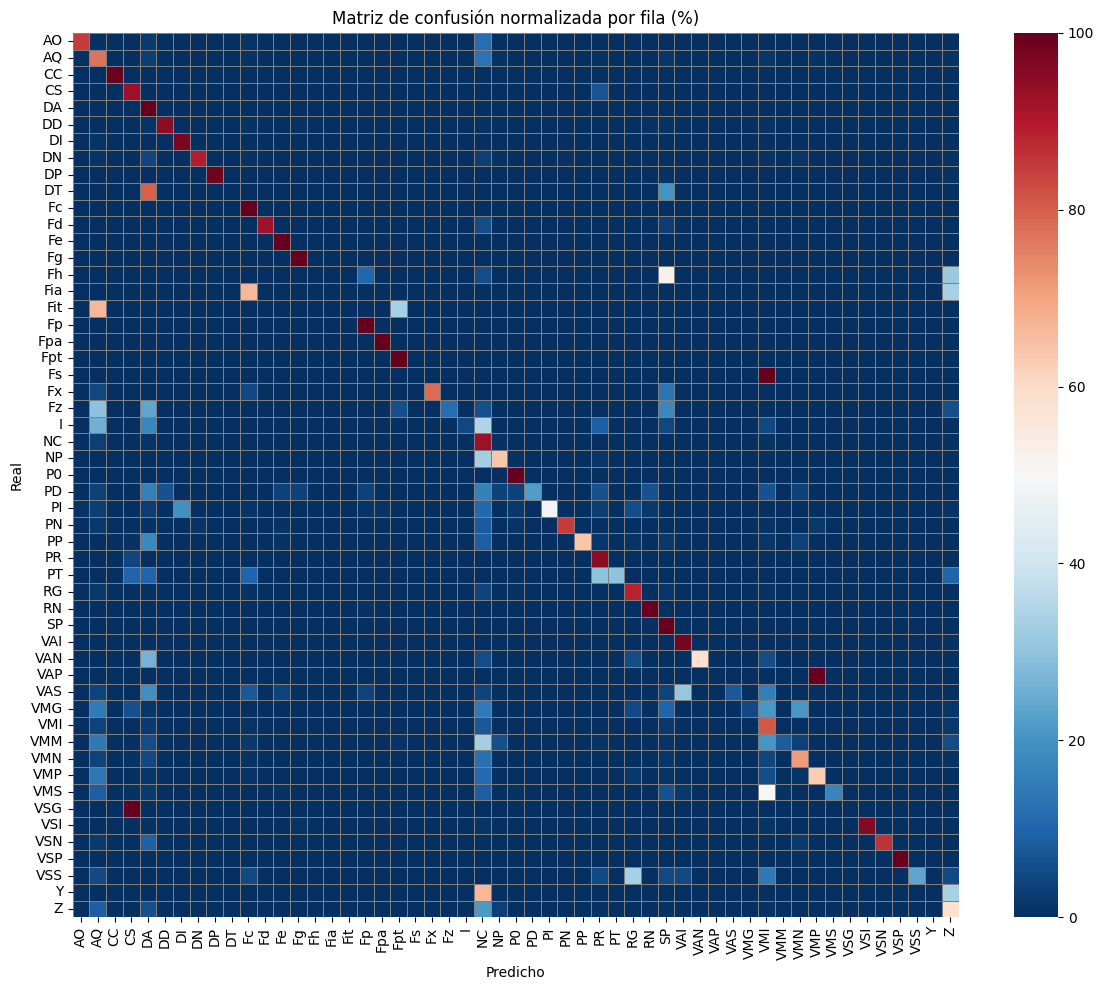

In [ ]:
plot_cm_heatmap(cm_norm, labels)

# 5. Analisis de resultados de aplicar el modelo *CategoricalHMM*

Analizar los resultados obtenidos. Si hay un alto nivel de acierto, ¿es eso cierto para todas las clases o hay algunas que no tienen un evaluación alta?

### Conclusiones genetales del modelo *CategoricalHMM*

1. Resultados de la diagonal:
     
     a. El head map que se muestra a nivel de tokens muestra que la diagonal aparece en rojo oscuro, que indica cercania al 100% para la mayoría de las etiquetas, que significa una gran cantidad de asciertos. Esto significa que HMM captura bien las transiciones entre etiquetas POS frecuentes y sus patrones de emisión.

2. Errores categoricos frecuentes:

     a. Algunas de las etiquetas muestran procentajes mas altos fuera de la diagonal segun la matriz de confución; este es el caso las etiquetas *Fp*, *Fc*, *Fpa*, *Fpt*, etc, que se confunden entre si, lo que quiere decir que el modelo distingue mal entre distintos signos, aunque sí sabe que es puntiación.

     b. Las etiqeutas de verbos, como *VMI*, *VMG*, *VMM*, *VMS*, *VSI* *VSN*, etc, tienen confuciones cruzadas, lo que quiere decir que las formas verbales menos frecuentes se etiquetan como otras formas mas similares.

     c. Para los determinantes y adjetivos, con etiquetas *DA*, *AQ*, *AO* tambien muestran algo de confusión segun la matriz obtenida, porque contextualmente suelen aparecer en lugares parecidos antes de sustantivos.

3. Etiquetas con bajo desempeño:
     
     a. Para algunas etiquetas como *Fz*, *Fe*, *RN*, *VMM*, *VMs* se observa que las diagonal es tenue, lo que indica procentajes de acierto bajos, es decir el modelo casi nunca las predice bien, confundienodse con etiquetas mas comounes como por ejemplo *VMI*

     b. Este resultado refleja un desvalance en el corpus, ya que hay clases muy poco frefuentes que no tienen suficiente información para que el HMM aprenda bien a distiguirlas.

4. Falsos positivos dispersos:
     
     a. En la matriz se muestran algunas celdas con colores mas claros en columnas distintas a la diagonal, lo uqe muestra  que el modelo tiende a sobreaprender ciertas clases como *NC* (sustantivo comun), *DA* (determinantes) y *SP* (preposición).


Con estas observaciones puede concluise que la mayoria de las etiquetas comunes como *NC*, *DA*, *SP*, y *VMI* tienen diagonal fuerte, lo que quiere decir que el modelo funciona bien para POS tagging basico. Además se muestran confuciones dentro de familias similares, como: Puntiación entre sí, distintas formas verbales, y determinantes y adjetivos. Sin embargo existen problemas con clases menos frecuentes, además de que la mayor cantidad errores son debidas al desvalance en el dataset que tambien puede verse en las graficas de distribución de cada una de las categorias.


Estos resultados de la matriz de confución son respaldados por los valores de accuracy obtenidos. Entre estos resultados se puede encontrar segun las etiquetas que:

1. *NC* (Sustantivos comunes): acc= 0.928 y count=12347. Donde se obtiene un muy buen desempeño, pues esta categoria es muy abundante.

2. *SP* (Preposiciones): acc = 0.999, count=8741. Es practicamente perfecto lo que muestra su facil predicción.

3. *DA* (articulos): acc=1.000, count=5034. Basicamente la predicción fue perfecta

4. *Fc* (coma): acc=1.00, count=2868, lo que quiere decir que las comas se reconocen a la perfección por el modelo.

5. *Z* (numerales): acc=0.581, count=1080. Es uno de los peores desempeños obtenidos, los numeros se confunden con sustantivos o simbolos, ademas de que su baja frecuencia relativa limita al modelo.

Además vemos que la diferencia de accuracy entre *NC* de 92.8% y *AQ* de 77.0% confirma que el modelo tiende a irse a sustantivos comunes cuando no tiene alternativas claras.

# 6. Aplicación del modelo CRF

Aplicar el modelo CRF visto en clase usando esp.train como datos de entrenamiento y esp.testb como datos de prueba.

Para realizar la aplicacion del modelo *CRF* primeramente aplicamos *df_to_sequences_crf* para transformar el dataframe de datos planos a un formato por oración para que  luego el CRF pueda entrenar y predecir secuencias completas.

In [ ]:
def df_to_sequences_crf(df: pd.DataFrame):
    """Devuelve listas por oración: words, pos, tags."""
    g = df.groupby("sentence", sort=True)
    words = g["Word"].apply(list).tolist()
    pos   = g["POS"].apply(list).tolist()
    tags  = g["Tag"].apply(list).tolist()
    return words, pos, tags

Ahora *word_shape_crf* transforma una palabra en una representación abstracta de su forma, que se usa como *feature adicional* en el modelo *CRF* para mejorar el reconocimiento de las entidades.

In [166]:
def word_shape_crf(w):
    out = []
    for ch in w:
        if ch.isupper(): out.append('X')
        elif ch.islower(): out.append('x')
        elif ch.isdigit(): out.append('d')
        else: out.append(ch)
    return ''.join(out)

La función *token2features* construye una ventana de caracteristicas para cada palabra, describiendo una palabra, luego anade información del contexto inmediato segun la palabra anterior y posterior, y tambien se marca si es inicio o fin de la oración.


In [ ]:
def token2features(sent_words, sent_pos, i):
    """Features para el token i (más contexto +/-1)."""
    w = sent_words[i]
    p = sent_pos[i]

    feats = {'bias': 1.0, 'w.lower': w.lower(), 'w.isupper': w.isupper(),
             'w.istitle': w.istitle(), 'w.isdigit': w.isdigit(),
             'w.shape': word_shape_crf(w), 'w.pref2': w[:2].lower(),
             'w.pref3': w[:3].lower(), 'w.suf2': w[-2:].lower(),
             'w.suf3': w[-3:].lower(), 'pos': p, 'pos.pref1': p[:1],}

    # Token previo
    if i > 0:
        w1 = sent_words[i-1]
        p1 = sent_pos[i-1]
        feats.update({'-1:w.lower': w1.lower(), '-1:w.istitle': w1.istitle(),
                      '-1:w.isupper': w1.isupper(), '-1:pos': p1,
                      '-1:w.shape': word_shape_crf(w1),})
    else:
        feats['BOS'] = True  # comienzo de oración

    # Token siguiente
    if i < len(sent_words)-1:
        w1 = sent_words[i+1]
        p1 = sent_pos[i+1]
        feats.update({
            '+1:w.lower': w1.lower(), '+1:w.istitle': w1.istitle(),
            '+1:w.isupper': w1.isupper(), '+1:pos': p1,
            '+1:w.shape': word_shape_crf(w1), })
    else:
        feats['EOS'] = True  # fin de oración

    return feats

Ahora *sent2features* toma una oración y genera la lista de vectores de features de token para alimentar el modelo *CRF*

In [ ]:
def sent2features_crf(sent_words, sent_pos):
    return [token2features(sent_words, sent_pos, i) for i in range(len(sent_words))]

La función *is_valid_seq* se asegura de que la oración no este vacia, que cada token tenga su etiqueta correspondiente, que los features sean diccionarios validos, y que no hayan valores no permitidos como vacios o NaNs dentro de las etiquetas.

In [ ]:
def is_valid_seq(X_seq, y_seq):
    # X_seq: lista de dicts de features; y_seq: lista de etiquetas (str)
    if not X_seq or not y_seq:                 # vacías
        return False
    if len(X_seq) != len(y_seq):               # longitudes distintas
        return False
    # validar cada feature dict y etiqueta
    for feats, lab in zip(X_seq, y_seq):
        if not isinstance(feats, dict):
            return False
        if lab is None or (isinstance(lab, float) and math.isnan(lab)):
            return False
        # evitar valores None/NaN dentro de features
        for k, v in feats.items():
            if v is None or (isinstance(v, float) and math.isnan(v)):
                return False
    return True

Finalmente la función *filter_invalid_sequences* permite filtrar cualquier oración no valida del dataset que haya quedado, conserva las que son validas y devuelve tambien los indices que se descartaaron luego de la limpieza. Esto evita que el modelo colapse por None values.

In [ ]:
def filter_invalid_sequences(X, y):
    X_clean, y_clean, bad_idx = [], [], []
    for i, (Xi, yi) in enumerate(zip(X, y)):
        if is_valid_seq(Xi, yi):
            X_clean.append(Xi)
            y_clean.append(yi)
        else:
            bad_idx.append(i)
    return X_clean, y_clean, bad_idx

In [ ]:
X_words_tr, X_pos_tr, y_tags_tr = df_to_sequences_crf(train_df)
X_words_te, X_pos_te, y_tags_te = df_to_sequences_crf(testb_df)

# Features por oración
X_tr = [sent2features_crf(w, p) for w, p in zip(X_words_tr, X_pos_tr)]
X_te = [sent2features_crf(w, p) for w, p in zip(X_words_te, X_pos_te)]

In [ ]:
X_tr_clean, y_tr_clean, bad_tr = filter_invalid_sequences(X_tr, y_tags_tr)
X_te_clean, y_te_clean, bad_te = filter_invalid_sequences(X_te, y_tags_te)

In [ ]:
print(f"Train: {len(X_tr)} secuencias -> válidas {len(X_tr_clean)} | inválidas {len(bad_tr)}")
print(f"Test : {len(X_te)} secuencias -> válidas {len(X_te_clean)} | inválidas {len(bad_te)}")

Train: 7263 secuencias -> válidas 7263 | inválidas 0
Test : 1364 secuencias -> válidas 1364 | inválidas 0


In [ ]:
assert len(X_tr_clean) == len(y_tr_clean) and len(X_tr_clean) > 0, "No hay secuencias válidas en train."
assert all(len(a)==len(b)>0 for a,b in zip(X_tr_clean, y_tr_clean)), "Desalineación en train."
assert all(isinstance(f, dict) for seq in X_tr_clean for f in seq), "Features mal formadas en train."
assert all(isinstance(lbl, str) for seq in y_tr_clean for lbl in seq), "Labels mal formadas en train."

In [ ]:
crf = sklearn_crfsuite.CRF(algorithm='lbfgs',
                           c1=0.1,           # Regularización L1
                           c2=0.1,           # Regularización L2
                           max_iterations=100,
                           all_possible_transitions=True,
                           verbose=False
                          )

In [ ]:
crf.fit(X_tr_clean, y_tr_clean)

CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.1,
    max_iterations=100)

In [ ]:
print("Tagger inicializado correctamente:", hasattr(crf, "tagger_") and crf.tagger_ is not None)

Tagger inicializado correctamente: True


In [ ]:
y_pred_te = crf.predict(X_te_clean)

print("\n== Reporte NER (seqeval) en TestB ==\n")
print(seqeval_classification_report(y_te_clean, y_pred_te, digits=3))

f1_weighted = metrics.flat_f1_score(y_te_clean, y_pred_te, average='weighted')
print(f"F1 (weighted, token-level): {f1_weighted:.3f}")


== Reporte NER (seqeval) en TestB ==

              precision    recall  f1-score   support

         LOC      0.802     0.768     0.785      1084
        MISC      0.660     0.521     0.582       340
         ORG      0.787     0.817     0.802      1400
         PER      0.855     0.886     0.870       735

   micro avg      0.797     0.788     0.792      3559
   macro avg      0.776     0.748     0.760      3559
weighted avg      0.794     0.788     0.790      3559

F1 (weighted, token-level): 0.971


# 7. Analisis de resultados de modelo CRF.

Analizar los resultados obtenidos. Si hay un alto nivel de acierto, ¿es eso cierto para todas las clases o hay algunas que no tienen un evaluación alta?

1. Resultados globales:

   a. Para el *F1 macro* con valor de 0.76 y *F1 micro* con valor de 0.79 indican un desempeño solido del modelo sobre el set test b.

   b. Para el *weighted avg* con valor de 0.79 es muy consistente con los *F1*, indica que a diferencia del modelo CategoricalHMM, en este caso el modelo no se ha sesgado hacia una sola clase.

2. Si observamos los valores por tipo de entidad podemos ver que:

   a. *LOC* (Lugares), con una *precisión* de 0.80, *recall* de 0.77 y *F1* de 0.785, muestra que el modelo reconoce bien lugares, aunque no de manera eprfecta, lo que puede ser causado por confución entre las entidades como *ORG* y *PER* en contextos ambiguos.

   b. *MISC* (miselaneos), con una *precisión* de 0.66, un *recall* de 0.52 y *F1* de 0.58. Esta es la clase mas debil, lo que puede deberse a que existen menos ejemplos en train. El modelo entonces tiende a perder entidades *MISC*.

   c. *ORG (organizaciones)*, con una *precisión* de 0.79, *Recall* de 0.82 y *F1* de 0.802, indica que el desempeño es muy bueno para esta categoria y esta ademas balanseado, por lo que el modelo generazila bien para organizaciones.

   d. *PER (Personas)*, con una *precision* de 0.85, *recall* de 0.89 y *F1* de 0.87 indica que es la mejor clase, ya que CRF parecer estar aprovechando mucho la informacioón de mayúsculas y contexto sintactico para calcular nombres propios.

Así, como conclusiones generales se puede decir que el modelo CRFfunciona muy bien para *NER* con el corpus usado. Mientras que el desbalance afecta mas qeu todo a *MISC*